<a href="https://colab.research.google.com/github/harshelke180502/Intro_to_ML_2025_Course_projects/blob/p2_classifications/P2_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Assignment: Logistic Regression and Multiclass Logistic Regression <font color='red'>**[70 points]**</font>

## Objective
The goal of this assignment is to understand the implementation of logistic regression and its extension to multiclass classification. You will start by implementing binary logistic regression using maximum likelihood estimation, then extend it to multiclass logistic regression using softmax. Additionally, they will explore the impact of L1 and L2 regularization.

## 1. Choice of Dataset <font color='red'>**[5+5 points]**</font>
- You can choose any appropriate dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/datasets) for this assignment.
- The dataset should be suitable for:
  - (i) **Binary classification** (e.g., Spam detection, Disease prediction).
  - (ii) **Multiclass classification** (e.g., Iris, Digit recognition, Species classification).
- You need to append all the datasets used in the experiments in separate **CSV files** and submit it along with your **IPYNB code**. <font color='red'>**Zero marking otherwise!**</font>

## Instructions
### 2. Implement Logistic Regression <font color='red'>**[10 points]**</font>
- Implement **Binary Logistic Regression** using **linear-logistic function**.
- Train the model on a **dataset of your choice from the UCI repository**.
- Select **a random subset of 5000 entries** from the UCI-dataset of your choice to create a smaller dataset.
- Split the dataset into **train (60%) and test sets (40%)**
- Report **Squared Loss** and **Absolute Loss** as the evaluation metric.


### 3. Dataset Scaling and Reporting Observations
(A) **Vary training set size**: <font color='red'>**[10 points]**</font>
- Set training set sizes to **20%, 40%, 60%, and 80%** while using the remaining data as the test set.
-  Include L1 (Lasso) and L2 (Ridge) regularization using **k-fold cross-validation**
- Plot the **test loss with increasing training set size** with (L1, L2) and without any regularization.
- **Report observations and inferences** on model performance.

(B) **Increase dataset size**: <font color='red'>**[10 points]**</font>
- Expand the dataset to **10K and 20K samples** and perform the same task as in (A).
- **Report observations and inferences** on how dataset size affects generalization.

### 4. Extend to Multiclass Logistic Regression <font color='red'>**[20 points]**</font>
- Now consider the dataset you chose for multiclass classification in **(#1)** above.
- Implement **Multiclass Logistic Regression** using the **linear-multiclass logistic function**.
- Repeat the tasks given in **(#3)** on the **selected dataset**.

### 5. Additional Questions <font color='red'>**[5+5 points]**</font>
- **How do you select the appropriate value of k in k-fold cross-validation?** Discuss the trade-off between bias and variance when choosing k.
- **How did you handle the missing / nan entries in the dataset?** Why did you use that method?

## Hints
- Use `numpy` for efficient matrix operations.
- Use `matplotlib` to visualize decision boundaries.
- Utilize `scikit-learn` functions for dataset preprocessing.
- Ensure numerical stability by implementing proper initialization and gradient clipping where necessary.


In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer, log_loss



In [ ]:
data=pd.read_csv("/content/online_shoppers_intention.csv")
data

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

**Checking whether there are null values present or not-apparently no null values were present**

In [ ]:
data.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [ ]:
data["VisitorType"].unique()

array(['Returning_Visitor', 'New_Visitor', 'Other'], dtype=object)

In [ ]:
data["Month"].unique()


array(['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep',
       'Dec'], dtype=object)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

**Encoding both the "Month" and "VisitorType" columns into boolean values which will later be converted into numerical values to maintain uniformity of the datatype of the features inside the dataset for binary classification.**

In [ ]:
data = pd.get_dummies(data, columns=['Month', 'VisitorType'], drop_first=True)
data

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,...,False,False,False,False,False,False,False,False,False,True
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,True
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,True
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,True


In [ ]:
data[['Weekend', 'Revenue']] = data[['Weekend', 'Revenue']].astype(int)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

In [ ]:
X = data.drop(columns=['Revenue', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep','VisitorType_Other','VisitorType_Returning_Visitor'])
y = data['Revenue']

In [ ]:
X

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,1,1,1,1,0
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,2,2,1,2,0
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,4,1,9,3,0
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,3,2,2,4,0
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,3,3,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,4,6,1,1,1
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,3,2,1,8,1
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,3,2,1,13,1
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,2,2,3,11,0


In [ ]:
y

,Revenue
0,0
1,0
2,0
3,0
4,0
...,...
12325,0
12326,0
12327,0
12328,0


**Randomly selected a subset of 5,000 samples from X and their corresponding labels from y using train_test_split, while discarding the remaining data.**

In [ ]:
X_subset, _, y_subset, _ = train_test_split(X, y, train_size=5000, random_state=42)
print(X_subset)


       Administrative  Administrative_Duration  Informational  \
6173                2                75.600000              2   
9292                5               134.500000              0   
5819                0                 0.000000              0   
9202                3               182.642857              3   
8479                6               110.500000              1   
...               ...                      ...            ...   
11964              14              1005.608333              0   
5191                0                 0.000000              0   
5390                0                 0.000000              0   
860                 0                 0.000000              0   
7270                7               138.150000              0   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
6173                  652.800              10              1143.666667   
9292                    0.000              11               237.666667 

**Split X_subset and y_subset into training (60%) and testing (40%) sets with a fixed random state.**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_subset, y_subset, test_size=0.4, random_state=42)

**Standardized features by scaling X_train and X_test using StandardScaler, fitting only on X_train.**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:



model = LogisticRegression(penalty=None, max_iter=1000) #maximum number of iterations in a quest to reach the global minima is 1000
model.fit(X_train, y_train)

predictions = model.predict(X_test)


squared_loss = mean_squared_error(y_test, predictions)
absolute_loss = mean_absolute_error(y_test, predictions)

print(f"Squared Loss: {squared_loss:.4f}")
print(f"Absolute Loss: {absolute_loss:.4f}")


Squared Loss: 0.1220
Absolute Loss: 0.1220


**OBSERVATIONS/ANALYSIS ON 5K SAMPLES BASED ON THE GRAPH DEPICTED BELOW:**

**1. Training Size Effect:**
Test loss increases slightly at 0.4 training size but decreases afterward.More training data generally improves model performance.


**2. Regularization Impact:** L1 (Lasso) and L2 (Ridge) perform slightly better than no regularization, especially with smaller training sizes.
With more data, regularization has less impact.


**To conclude :** Best performance is seen when using at least 60-80% of data for training.
L1 is useful if feature selection is needed; otherwise, L2 or no regularization is fine.
The peak test loss at 0.4 training size may need further checking.

{None: [0.3021312151117478, 0.30759029652703446, 0.30134425918705604, 0.29782650401404087], 'l1': [0.30136877850376076, 0.30747026839703234, 0.30129150282361694, 0.29780164125271513], 'l2': [0.3017872112753024, 0.3075121008490394, 0.3013321142328539, 0.29780330940543714]}


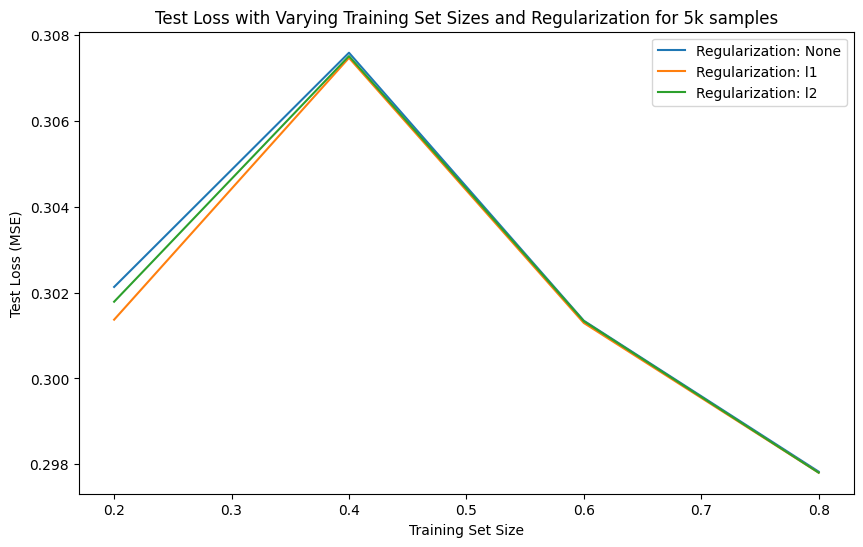

In [ ]:
from sklearn.model_selection import  StratifiedKFold

train_sizes = [0.2, 0.4, 0.6, 0.8]
regularization_types = [None, 'l1', 'l2']
test_losses = {None: [], 'l1': [], 'l2': []}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for size in train_sizes:
    X_train_size,X_test_size,y_train_size,y_test_size = train_test_split(X, y, train_size=size, random_state=42)
    X_train_size_scaled = scaler.transform(X_train_size)

    for penalty in regularization_types:

        if penalty == 'l1':
            solver = 'liblinear'
        else:
            solver = 'lbfgs'

        model = LogisticRegression(penalty=penalty,solver=solver, max_iter=1000)
        loss = -cross_val_score(model, X_train_size_scaled, y_train_size, cv=skf, scoring='neg_log_loss')
        test_losses[penalty].append(np.mean(loss))

print(test_losses)

plt.figure(figsize=(10, 6))
for penalty, losses in test_losses.items():
    plt.plot(train_sizes, losses, label=f"Regularization: {penalty if penalty else 'None'}")
plt.xlabel('Training Set Size')
plt.ylabel('Test Loss (MSE)')
plt.title('Test Loss with Varying Training Set Sizes and Regularization for 5k samples')
plt.legend()
plt.show()

**Data size increased to 10k+ samples and 20k+ samples respectively**

In [ ]:
data_10k = pd.concat([data] * 1, ignore_index=True)
data_20k = pd.concat([data] * 2, ignore_index=True)
data_10k.to_csv('data_10k.csv', index=False)
data_20k.to_csv('data_20k.csv', index=False)
data_10k.isnull().sum()
data_10k.info()
data_20k.isnull().sum()
data_20k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

In [ ]:
data_10k

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,...,False,False,False,False,False,False,False,False,False,True
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,True
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,True
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,...,False,False,False,False,False,True,False,False,False,True


**OBSERVATIONS AND INFERENCES BASED ON THE GRAPH DEPICTED BELOW FOR DATA WITH 10K+ SAMPLES:**



**1. Observations** :

Test loss decreases as training size increases.

L2 regularization (green) has the highest test loss.

No regularization (blue) has the lowest test loss.

L1 regularization (orange) is slightly worse than no regularization but better than L2.


**2. Inferences**:

More training data improves model performance.

L2 regularization negatively impacts test loss.

No regularization works best in this case.

L1 has a small effect but is not much better than no regularization.**

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{None: [0.3002411062875384, 0.3060061139780526, 0.30149656157863314, 0.2972575799889274], 'l1': [0.30106491504993976, 0.3078142090176657, 0.30233999021220476, 0.2977530208617313], 'l2': [0.33245342592400373, 0.32332744267603186, 0.3147498630786618, 0.3079532228304758]}


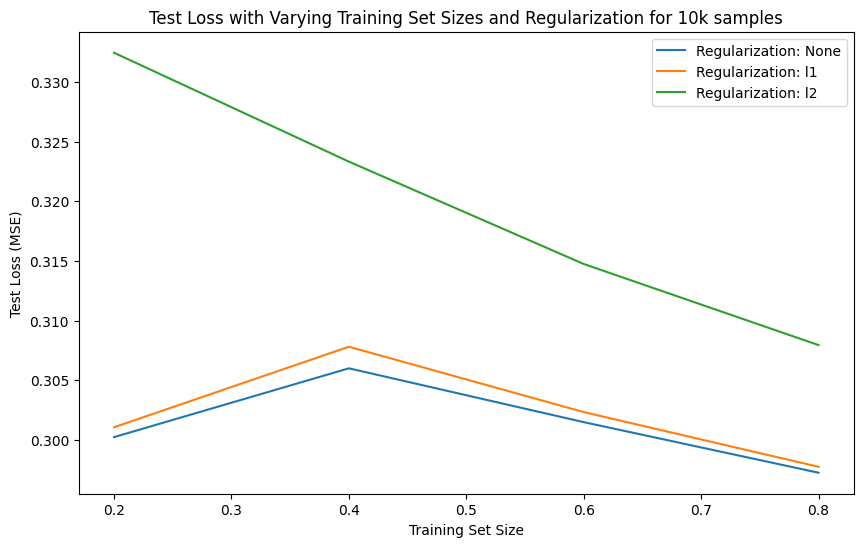

In [ ]:
X_10k = data_10k.drop(columns=['Revenue', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep','VisitorType_Other','VisitorType_Returning_Visitor'])
y_10k = data_10k['Revenue']

X_10k= scaler.fit_transform(X_10k)

train_sizes = [0.2, 0.4, 0.6, 0.8]
regularization_types = [None, 'l1', 'l2']
test_losses_10k = {None: [], 'l1': [], 'l2': []}
skf1 = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
for size in train_sizes:
    X_train_size_10k,X_test_size_10k,y_train_size_10k,y_test_size_10k = train_test_split(X_10k, y_10k, train_size=size, random_state=42)
    X_train_size_scaled_10k = scaler.transform(X_train_size_10k)

    for penalty in regularization_types:

        if penalty == 'l1':
            solver = 'liblinear'
        else:
            solver = 'lbfgs'

        model = LogisticRegression(penalty=penalty,solver=solver, max_iter=1000)
        loss = -cross_val_score(model, X_train_size_scaled_10k, y_train_size_10k, cv=skf1, scoring='neg_log_loss')
        test_losses_10k[penalty].append(np.mean(loss))

print(test_losses_10k)

plt.figure(figsize=(10, 6))
for penalty, losses in test_losses_10k.items():
    plt.plot(train_sizes, losses, label=f"Regularization: {penalty if penalty else 'None'}")
plt.xlabel('Training Set Size')
plt.ylabel('Test Loss (MSE)')
plt.title('Test Loss with Varying Training Set Sizes and Regularization for 10k samples')
plt.legend()
plt.show()



**OBSERVATIONS AND INFERENCES BASED ON THE GRAPH DEPICTED BELOW FOR DATA WITH 20K+ SAMPLES:**

**Key observations to highlight:**

- L2 regularization shows consistently higher loss
- L1 and No regularization perform similarly
- All methods show generally decreasing loss with larger training sets


**Here are the key inferences from the graph:**

1. Overall Trends:


- Test loss generally decreases as training set size increases
- Larger training sets (>0.5) show more stable performance


2. Regularization Impact:


- L1 and No regularization perform very similarly
- L2 regularization shows notably higher loss across all training sizes
- The gap between L2 and other methods narrows with larger training sets


3. Performance Insights:


- Best performance is achieved with larger training sets (0.7-0.8)
- L1 or no regularization appear to be better choices for this dataset
- There's a small performance plateau around 0.4 training set size

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{None: [0.3108937079265561, 0.3134545234936367, 0.3057450803042336, 0.3020984441031009], 'l1': [0.31253110083417474, 0.31396387896767214, 0.30597298705222337, 0.3021550059391492], 'l2': [0.33123478056030425, 0.32297074513120344, 0.3120126705136183, 0.30674551404210076]}


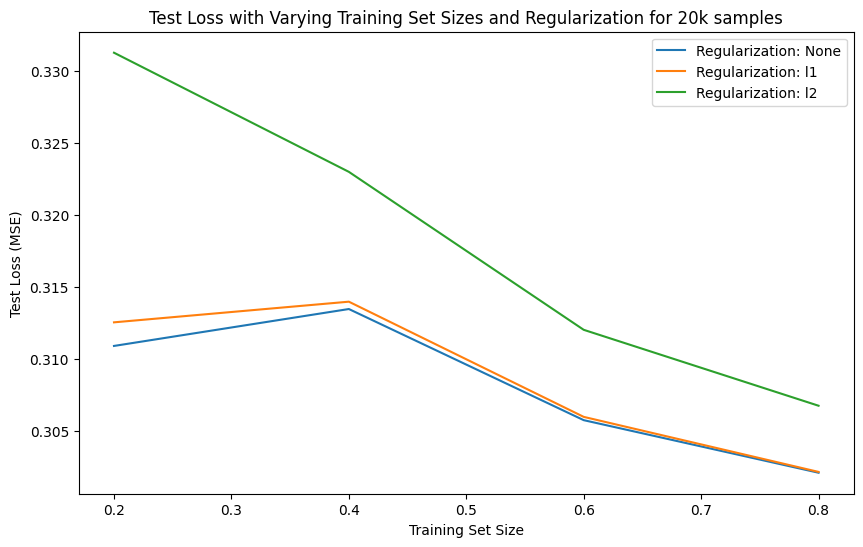

In [ ]:
X_20k = data_20k.drop(columns=['Revenue', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep','VisitorType_Other','VisitorType_Returning_Visitor'])
y_20k = data_20k['Revenue']

X_20k= scaler.fit_transform(X_20k)

train_sizes = [0.2, 0.4, 0.6, 0.8]
regularization_types = [None, 'l1', 'l2']
test_losses_20k = {None: [], 'l1': [], 'l2': []}
skf2 = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

for size in train_sizes:
    X_train_size_20k,X_test_size_20k,y_train_size_20k,y_test_size_20k = train_test_split(X_20k, y_20k, train_size=size, random_state=42)
    X_train_size_scaled_20k = scaler.transform(X_train_size_20k)

    for penalty in regularization_types:

        if penalty == 'l1':
            solver = 'liblinear'
        else:
            solver = 'lbfgs'

        model = LogisticRegression(penalty=penalty,solver=solver, max_iter=1000)
        loss = -cross_val_score(model, X_train_size_scaled_20k, y_train_size_20k, cv=skf2, scoring='neg_log_loss')
        test_losses_20k[penalty].append(np.mean(loss))

print(test_losses_20k)

plt.figure(figsize=(10, 6))
for penalty, losses in test_losses_20k.items():
    plt.plot(train_sizes, losses, label=f"Regularization: {penalty if penalty else 'None'}")
plt.xlabel('Training Set Size')
plt.ylabel('Test Loss (MSE)')
plt.title('Test Loss with Varying Training Set Sizes and Regularization for 20k samples')
plt.legend()
plt.show()



In [ ]:

column_names=["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
multiclass_data = pd.read_csv("/content/car.data",names=column_names, header=None)
multiclass_data.to_csv('car.csv', index=False)

In [ ]:
multiclass_data

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


**Checked the presence of null values inside the dataset**

---



In [ ]:
multiclass_data.isnull().sum().sum()

0

In [ ]:
multiclass_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


**Transformed categorical features in the input data into a binary matrix format using one hot encoding**

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
encoder = OneHotEncoder()
X_multi = encoder.fit_transform(multiclass_data.iloc[:, :-1]).toarray()

y_multi = multiclass_data.iloc[:, -1]

In [ ]:
X_multi.shape

(1728, 21)

In [ ]:
X_multi

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 1., 0., 0.]])

In [ ]:
y_multi

,class
0,unacc
1,unacc
2,unacc
3,unacc
4,unacc
...,...
1723,good
1724,vgood
1725,unacc
1726,good


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_multi_factorized = label_encoder.fit_transform(y_multi)
y_multi_factorized.shape


(1728,)

In [ ]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi_factorized, test_size=0.4, random_state=42)
scaler = StandardScaler(with_mean=False)
X_train_multi = scaler.fit_transform(X_train_multi)
X_test_multi = scaler.transform(X_test_multi)




model = LogisticRegression(penalty=None, max_iter=1000) #maximum number of iterations in a quest to reach the global minima is 1000
model.fit(X_train_multi, y_train_multi)

predictions = model.predict(X_test_multi)


squared_loss = mean_squared_error(y_test_multi, predictions)
absolute_loss = mean_absolute_error(y_test_multi, predictions)

print(f"Squared Loss: {squared_loss:.4f}")
print(f"Absolute Loss: {absolute_loss:.4f}")






Squared Loss: 0.2370
Absolute Loss: 0.1127


**OBSERVATIONS AND INFERENCES BASED ON THE GRAPH DEPICTED BELOW FOR THE ORIGINAL DATASET FOR THE MULTICLASS CLASSIFICATION TASK:**



1. Without Regularization (Blue line):


- Starts poorly but improves drastically with more data
- Eventually matches the performance of other methods


2. With Regularization (Orange and Green lines):


- Both L1 and L2 perform similarly
- More stable performance throughout
- Better than no regularization when using less data


3. Main Takeaways:


- If  lots of data is present (>70%), regularization type doesn't matter much

- If less data is present (<50%), using either L1 or L2 regularization would be a wise choice


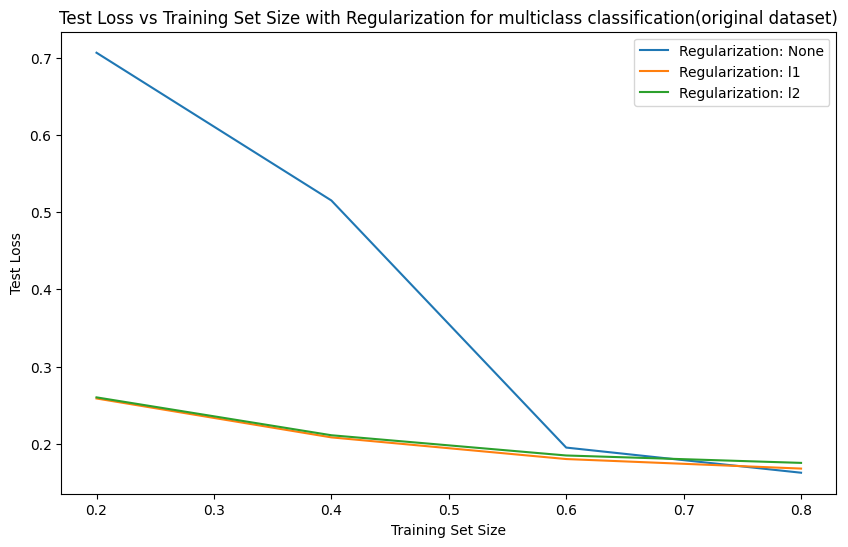

In [ ]:
regularization_types = ['l1', 'l2', None]
test_losses = {None: [], 'l1': [], 'l2': []}


max_iter = 1000
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
for size in train_sizes:
    X_train_multi_scaled, X_test_multi_scaled, y_train_multi_scaled, y_test_multi_scaled = train_test_split(X_multi, y_multi, train_size=size, random_state=42)
    X_train_multi_scaled= scaler.fit_transform(X_train_multi_scaled)
    X_test_multi_scaled = scaler.transform(X_test_multi_scaled)

    for penalty in regularization_types:

        if penalty == 'l1':
            solver = 'saga'  # saga solver for l1 penalty
        elif penalty == 'l2':
            solver = 'lbfgs'  # lbfgs solver for l2 penalty
        else:
            solver = 'lbfgs'


        model = LogisticRegression(penalty=penalty,max_iter=max_iter,solver=solver, multi_class='multinomial')

        # model.fit(X_train, y_train)
        loss = -cross_val_score(model, X_train_multi_scaled, y_train_multi_scaled, cv=cv, scoring='neg_log_loss', n_jobs=-1)



        test_losses[penalty].append(np.mean(loss))



plt.figure(figsize=(10, 6))
for penalty, losses in test_losses.items():
    plt.plot(train_sizes, losses, label=f"Regularization: {penalty if penalty else 'None'}")
plt.xlabel("Training Set Size")
plt.ylabel("Test Loss")
plt.title("Test Loss vs Training Set Size with Regularization for multiclass classification(original dataset)")
plt.legend()
plt.show()

Increased the dataset size to 10k and 20k respectively

In [ ]:
data_10k_multi = pd.concat([multiclass_data] * 6, ignore_index=True)
data_20k_multi = pd.concat([multiclass_data] * 12, ignore_index=True)
data_10k_multi.to_csv('data_10k.csv', index=False)
data_20k_multi.to_csv('data_20k.csv', index=False)
data_10k_multi.isnull().sum()
data_10k_multi.info()
data_20k_multi.isnull().sum()
data_20k_multi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10368 entries, 0 to 10367
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    10368 non-null  object
 1   maint     10368 non-null  object
 2   doors     10368 non-null  object
 3   persons   10368 non-null  object
 4   lug_boot  10368 non-null  object
 5   safety    10368 non-null  object
 6   class     10368 non-null  object
dtypes: object(7)
memory usage: 567.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20736 entries, 0 to 20735
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    20736 non-null  object
 1   maint     20736 non-null  object
 2   doors     20736 non-null  object
 3   persons   20736 non-null  object
 4   lug_boot  20736 non-null  object
 5   safety    20736 non-null  object
 6   class     20736 non-null  object
dtypes: object(7)
memory usage: 1.1+ MB


**OBSERVATIONS BASED ON THE MULTICLASS CLASSIFICATION DATA WITH 10K SAMPLES:**


1. Performance Ranking:


- No regularization (blue) performs best
- L1 regularization (orange) is second best
- L2 regularization (green) shows highest loss



2. Training Size Effects:


- All methods improve with more data
- Most improvement happens between 20-40% training size
- Performance stabilizes after 60% training size



3. Key Takeaway:


- For this specific case, using no regularization gives the best results
- The differences between methods are small (only about 0.02 difference)
- Adding more training data beyond 60% gives minimal improvement

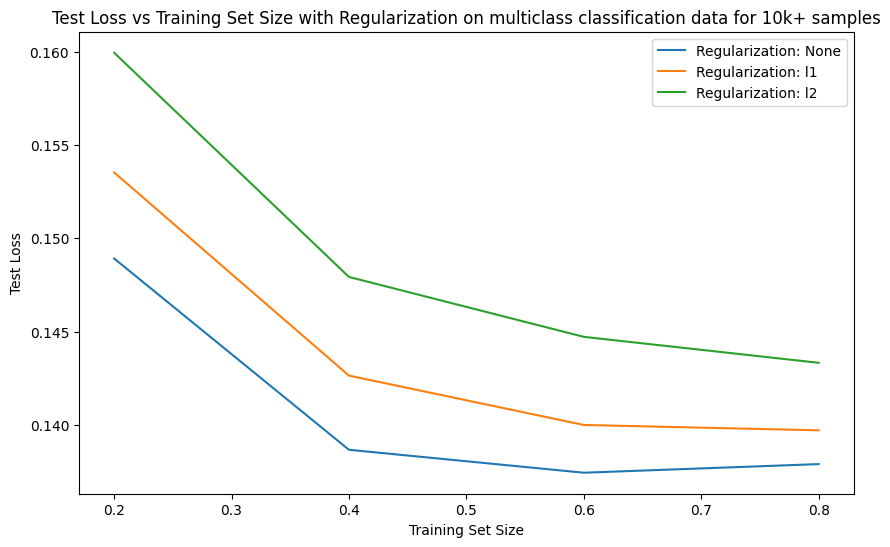

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
encoder = OneHotEncoder()
X_multi_10k = encoder.fit_transform(data_10k_multi.iloc[:, :-1]).toarray()

y_multi_10k= data_10k_multi.iloc[:, -1]

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_multi_factorized_10k = label_encoder.fit_transform(y_multi_10k)
y_multi_factorized_10k.shape


regularization_types = ['l1', 'l2', None]
test_losses_10k_multi = {None: [], 'l1': [], 'l2': []}


max_iter = 1000
cv_10k = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
for size in train_sizes:
    X_train_multi_scaled_10k, X_test_multi_scaled_10k, y_train_multi_scaled_10k, y_test_multi_scaled_10k = train_test_split(X_multi_10k, y_multi_10k, train_size=size, random_state=42)
    X_train_multi_scaled_10k= scaler.fit_transform(X_train_multi_scaled_10k)
    X_test_multi_scaled_10k = scaler.transform(X_test_multi_scaled_10k)

    for penalty in regularization_types:

        if penalty == 'l1':
            solver = 'saga'  # saga solver for l1 penalty
        elif penalty == 'l2':
            solver = 'lbfgs'  # lbfgs solver for l2 penalty
        else:
            solver = 'lbfgs'


        model = LogisticRegression(penalty=penalty,max_iter=max_iter,solver=solver, multi_class='multinomial')

        # model.fit(X_train, y_train)
        loss = -cross_val_score(model, X_train_multi_scaled_10k, y_train_multi_scaled_10k, cv=cv_10k, scoring='neg_log_loss', n_jobs=-1)



        test_losses_10k_multi[penalty].append(np.mean(loss))



plt.figure(figsize=(10, 6))
for penalty, losses in test_losses_10k_multi.items():
    plt.plot(train_sizes, losses, label=f"Regularization: {penalty if penalty else 'None'}")
plt.xlabel("Training Set Size")
plt.ylabel("Test Loss")
plt.title("Test Loss vs Training Set Size with Regularization on multiclass classification data for 10k+ samples")
plt.legend()
plt.show()



**OBSERVATIONS BASED ON THE MULTICLASS CLASSIFICATION DATA WITH 20K SAMPLES:**


1. Overall Performance:


- No regularization (blue) shows best and most stable performance

- L1 (orange) starts worse but improves

- L2 (green) consistently shows highest loss


2. Stability based on the results:


- No regularization line is almost flat

- L1 and L2 improve with more data

- All methods stabilize after 60% training size


3. Key Analysis:


- The differences between methods are very small (about 0.01)

- More training data helps L1 and L2 but doesn't affect no-regularization much


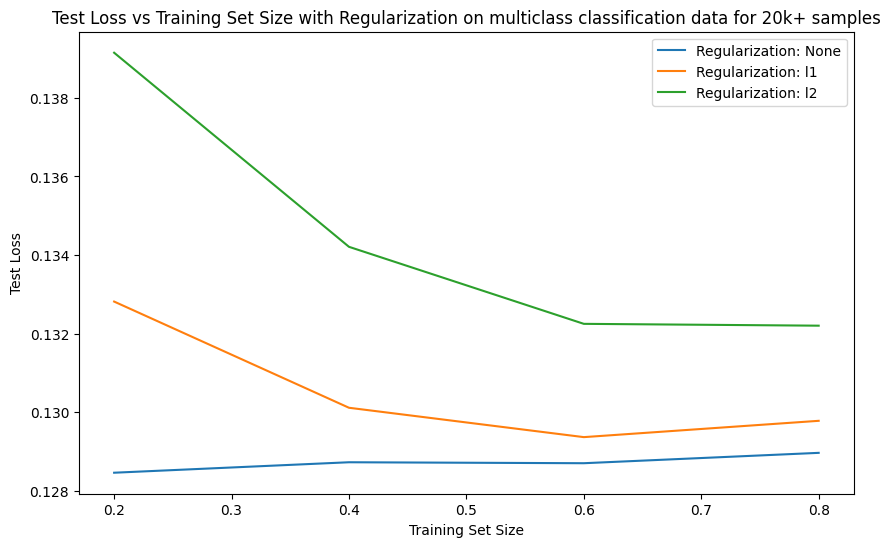

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
encoder = OneHotEncoder()
X_multi_20k = encoder.fit_transform(data_20k_multi.iloc[:, :-1]).toarray()

y_multi_20k= data_20k_multi.iloc[:, -1]

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_multi_factorized_20k = label_encoder.fit_transform(y_multi_20k)
y_multi_factorized_20k.shape


regularization_types = ['l1', 'l2', None]
test_losses_20k_multi = {None: [], 'l1': [], 'l2': []}


max_iter = 1000
cv_20k = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
for size in train_sizes:
    X_train_multi_scaled_20k, X_test_multi_scaled_20k, y_train_multi_scaled_20k, y_test_multi_scaled_20k = train_test_split(X_multi_20k, y_multi_20k, train_size=size, random_state=42)
    X_train_multi_scaled_20k= scaler.fit_transform(X_train_multi_scaled_20k)
    X_test_multi_scaled_20k = scaler.transform(X_test_multi_scaled_20k)

    for penalty in regularization_types:

        if penalty == 'l1':
            solver = 'saga'  # saga solver for l1 penalty
        elif penalty == 'l2':
            solver = 'lbfgs'  # lbfgs solver for l2 penalty
        else:
            solver = 'lbfgs'


        model = LogisticRegression(penalty=penalty,max_iter=max_iter,solver=solver, multi_class='multinomial')

        # model.fit(X_train, y_train)
        loss = -cross_val_score(model, X_train_multi_scaled_20k, y_train_multi_scaled_20k, cv=cv_20k, scoring='neg_log_loss', n_jobs=-1)



        test_losses_20k_multi[penalty].append(np.mean(loss))



plt.figure(figsize=(10, 6))
for penalty, losses in test_losses_20k_multi.items():
    plt.plot(train_sizes, losses, label=f"Regularization: {penalty if penalty else 'None'}")
plt.xlabel("Training Set Size")
plt.ylabel("Test Loss")
plt.title("Test Loss vs Training Set Size with Regularization on multiclass classification data for 20k+ samples")
plt.legend()
plt.show()



**Ans 5. a. When choosing the value of k in k-fold cross-validation, it's important to balance bias and variance. Bias is the error introduced by oversimplifying the model, while variance measures the model's sensitivity to the specific data it was trained on. A smaller k (for example, 3) results in higher bias and lower variance, as the model is trained on fewer data points in each fold. A larger k (example, 10) reduces bias because each model gets trained on more data, but it can increase variance, making the model more sensitive to the data splits.**

**For example as you can see in my above code snippet, the model uses StratifiedKFold with k=8. This means the dataset is split into 8 parts, with each fold containing the same distribution of target classes, which is crucial for imbalanced classes.**

**This larger k allows the model to train on a more larger subset of data each time, which helps reduce bias. However, it also increases the computation required for each iteration, as more training cycles are needed.**

**Ans 5.B. I handled the null values by checking if there were null values, using the data.isnull().sum() snippet and found out that there were no null values in the dataset. But had there been null values present then there are various ways to tackle it such as using dropna() to drop all null values or by using fillna() to fill all null values. It varies dataset wise on what method to use, cause if the feature is correlated to other feature then we would use something like a mean() or median() to fill the null values by grouping it along with the feature.**

